<a href="https://colab.research.google.com/github/juanepstein99/MessiEvolution/blob/main/Messi_Evolution_Hackaton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Messi Evolution: Data vs Narrative**

**Project Goal:**

This project analyzes Lionel Messi's statistical evolution over time and compares it with the change in media narrative before and after Argentina won the 2022 World Cup.

**Main Question:**
Did Messi's performance change after Qatar 2022, or did the public narrative change more than the data?

In [114]:
# import libraries for data analysis and plots

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

# style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [115]:
# read the csv files

messi = pd.read_csv("messi.csv")
headlines = pd.read_csv("messi_headlines.csv")

# First Look at the Data

First, we check the first rows of each datasets to understand the structure of the data

In [116]:
# first rows of messi dataset
messi.head()

,full_name,age,birthday,birthday_GMT,league,season,position,Current Club,minutes_played_overall,minutes_played_home,...,annual_salary_eur,annual_salary_eur_percentile,clean_sheets_percentage_percentile_overall,min_per_card_percentile_overall,cards_per90_percentile_overall,booked_over05_overall,booked_over05_percentage_overall,booked_over05_percentage_percentile_overall,shirt_number,market_value_euro
0,Lionel Messi,38,551516400,1987/06/24,WC Qualification South America,2026,Forward,Argentina,957,564,...,NaN,NaN,92.0,27.0,27.0,0.0,0.0,33.0,10.0,NaN
1,Lionel Messi,38,551516400,1987/06/24,MLS,2026,Forward,Inter Miami,270,0,...,NaN,NaN,30.0,66.0,66.0,0.0,0.0,67.0,10.0,NaN
2,Lionel Messi,38,551516400,1987/06/24,Club Friendlies 1,2026,Forward,Inter Miami,82,0,...,NaN,NaN,94.0,97.0,97.0,0.0,0.0,97.0,10.0,NaN
3,Lionel Messi,38,551516400,1987/06/24,CONCACAF Champions League,2026,Forward,Inter Miami,90,0,...,NaN,NaN,99.0,83.0,83.0,0.0,0.0,83.0,10.0,NaN
4,Lionel Messi,38,551516400,1987/06/24,Club Friendlies 1,2025,Forward,Inter Miami,367,66,...,NaN,NaN,77.0,81.0,81.0,0.0,0.0,-1.0,10.0,NaN


In [117]:
# first rows of headlines dataset
headlines.head()

,year,source,headline,period,sentiment
0,2014,BBC,Messi falls short as Argentina lose World Cup ...,pre_qatar,negative
1,2014,Guardian,Messi unable to deliver World Cup for Argentina,pre_qatar,negative
2,2014,ESPN,Argentina heartbreak as Messi misses World Cup...,pre_qatar,negative
3,2015,BBC,Messi struggles in Copa America final defeat,pre_qatar,negative
4,2015,Guardian,Messi brilliance not enough in Copa America fi...,pre_qatar,negative


# Dataset Exploration

In this step, we check:
- number of columns
- data types
- missing values
- summary statistics

In [118]:
# Basic information about Messi dataset
messi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Columns: 275 entries, full_name to market_value_euro
dtypes: float64(234), int64(34), object(7)
memory usage: 199.9+ KB


In [119]:
# Basic statistics for numeric columns
messi.describe()

,age,birthday,minutes_played_overall,minutes_played_home,minutes_played_away,appearances_overall,appearances_home,appearances_away,goals_overall,goals_home,...,annual_salary_eur,annual_salary_eur_percentile,clean_sheets_percentage_percentile_overall,min_per_card_percentile_overall,cards_per90_percentile_overall,booked_over05_overall,booked_over05_percentage_overall,booked_over05_percentage_percentile_overall,shirt_number,market_value_euro
count,93.000000,9.300000e+01,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,...,3.000000e+00,3.0,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,0.0
mean,36.483871,5.515159e+08,822.129032,428.150538,393.978495,9.827957,5.129032,4.698925,8.408602,5.107527,...,2.102000e+07,99.0,62.314286,46.057143,41.742857,0.457143,4.200000,37.942857,12.857143,NaN
std,1.028009,3.675368e+03,972.724069,498.246904,484.574017,11.446115,5.810833,5.757386,11.923886,7.059472,...,1.687060e+07,0.0,36.397133,31.473558,28.475317,0.950011,9.247575,27.050000,7.100716,NaN
min,35.000000,5.514912e+08,64.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.116000e+07,99.0,2.000000,11.000000,11.000000,0.000000,0.000000,-1.000000,10.000000,NaN
25%,36.000000,5.515164e+08,176.000000,90.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,...,1.128000e+07,99.0,33.500000,16.500000,16.500000,0.000000,0.000000,17.000000,10.000000,NaN
50%,37.000000,5.515164e+08,450.000000,239.000000,180.000000,5.000000,3.000000,2.000000,3.000000,2.000000,...,1.140000e+07,99.0,74.000000,30.000000,30.000000,0.000000,0.000000,33.000000,10.000000,NaN
75%,37.000000,5.515164e+08,900.000000,450.000000,450.000000,11.000000,5.000000,5.000000,8.000000,6.000000,...,2.595000e+07,99.0,96.000000,81.000000,64.000000,0.500000,0.000000,57.000000,10.000000,NaN
max,38.000000,5.515164e+08,3374.000000,1710.000000,1664.000000,38.000000,19.000000,19.000000,50.000000,35.000000,...,4.050000e+07,99.0,99.000000,99.000000,99.000000,4.000000,40.000000,98.000000,30.000000,NaN


In [120]:
# Shape of the dataset
messi.shape

(93, 275)

In [121]:
# All column names
print(messi.columns)

Index(['full_name', 'age', 'birthday', 'birthday_GMT', 'league', 'season',
       'position', 'Current Club', 'minutes_played_overall',
       'minutes_played_home',
       ...
       'annual_salary_eur', 'annual_salary_eur_percentile',
       'clean_sheets_percentage_percentile_overall',
       'min_per_card_percentile_overall', 'cards_per90_percentile_overall',
       'booked_over05_overall', 'booked_over05_percentage_overall',
       'booked_over05_percentage_percentile_overall', 'shirt_number',
       'market_value_euro'],
      dtype='object', length=275)


## Clean Column Names

We make column names easier to use:
- lowercase
- replace spaces with underscores

In [122]:
# clean column names

messi.columns = messi.columns.str.lower().str.replace(" ", "_")
headlines.columns = headlines.columns.str.lower().str.replace(" ", "_")

In [123]:
# check cleaned column names
print(messi.columns)
print(headlines.columns)

Index(['full_name', 'age', 'birthday', 'birthday_gmt', 'league', 'season',
       'position', 'current_club', 'minutes_played_overall',
       'minutes_played_home',
       ...
       'annual_salary_eur', 'annual_salary_eur_percentile',
       'clean_sheets_percentage_percentile_overall',
       'min_per_card_percentile_overall', 'cards_per90_percentile_overall',
       'booked_over05_overall', 'booked_over05_percentage_overall',
       'booked_over05_percentage_percentile_overall', 'shirt_number',
       'market_value_euro'],
      dtype='object', length=275)
Index(['year', 'source', 'headline', 'period', 'sentiment'], dtype='object')


## Select Relevant Columns

The Messi dataset has many columns, but we only keep the ones needed for this project.

We focus on:
- season
- age
- matches
- goals
- assists
- minutes

In [124]:
# keep only the columns I need

messi = messi[[
    "season",
    "age",
    "appearances_overall",
    "goals_overall",
    "assists_overall",
    "minutes_played_overall"
]]

In [125]:
# rename columns to simpler names

messi = messi.rename(columns={
    "appearances_overall": "matches",
    "goals_overall": "goals",
    "assists_overall": "assists",
    "minutes_played_overall": "minutes"
})

In [126]:
# check final columns

print(messi.columns)
messi.head()

Index(['season', 'age', 'matches', 'goals', 'assists', 'minutes'], dtype='object')


,season,age,matches,goals,assists,minutes
0,2026,38,12,8,3,957
1,2026,38,3,3,1,270
2,2026,38,1,1,1,82
3,2026,38,1,0,0,90
4,2025,38,5,2,2,367


## Missing Values

We check for missing values and remove incomplete rows if needed.

In [127]:
# Count missing values
messi.isnull().sum()

,0
season,0
age,0
matches,0
goals,0
assists,0
minutes,0


In [128]:
# Drop missing values
messi = messi.dropna()

## Feature Engineering

In this step we create new metrics to better measure Messi's performance.

Instead of looking only at goals or assists separately, we create a metric called
"goal contribution", which combines both.

In [129]:
# Create a new metric that combines goals and assists

messi["goal_contribution"] = messi["goals"] + messi["assists"]

In [130]:
# preview the dataset with the new column

messi.head()

,season,age,matches,goals,assists,minutes,goal_contribution
0,2026,38,12,8,3,957,11
1,2026,38,3,3,1,270,4
2,2026,38,1,1,1,82,2
3,2026,38,1,0,0,90,0
4,2025,38,5,2,2,367,4


## Aggregate Data by Season

Each season contains multiple competitions (league, champions league, cups).

To analyze Messi's full seasonal performance, we aggregate all competitions
into a single record per season.

In [131]:
# create season_year from season

messi["season_year"] = messi["season"].astype(str).str[:4]
messi["season_year"] = pd.to_numeric(messi["season_year"], errors="coerce")

In [132]:
# aggregate all competitions per season

messi_season = messi.groupby("season_year").agg({
    "age": "first",
    "matches": "sum",
    "goals": "sum",
    "assists": "sum",
    "minutes": "sum"
}).reset_index()

In [133]:
# recompute performance metrics after aggregation

messi_season["goal_contribution"] = messi_season["goals"] + messi_season["assists"]

messi_season["goals_per_match"] = messi_season["goals"] / messi_season["matches"]

messi_season["assists_per_match"] = messi_season["assists"] / messi_season["matches"]

messi_season["involvement_per_match"] = messi_season["goal_contribution"] / messi_season["matches"]

In [134]:
# sort seasons chronologically

messi_season = messi_season.sort_values("season_year")

messi_season.head()

,season_year,age,matches,goals,assists,minutes,goal_contribution,goals_per_match,assists_per_match,involvement_per_match
0,2006,35,3,1,1,91,2,0.333333,0.333333,0.666667
1,2008,37,31,23,0,2517,23,0.741935,0.000000,0.741935
2,2009,36,50,43,10,4096,53,0.860000,0.200000,1.060000
3,2010,36,53,46,26,4482,72,0.867925,0.490566,1.358491
4,2011,36,51,68,26,4527,94,1.333333,0.509804,1.843137


### Insight

Now the dataset represents Messi's full seasonal performance.
Each row corresponds to one complete season across all competitions.

## Defining the Qatar 2022 Milestone

The 2022 World Cup represents a major moment in Messi's career.

To analyze its impact, we divide the dataset into two periods:

• Pre-Qatar: seasons before 2022  
• Post-Qatar: seasons from 2022 onward

In [135]:
# create period column

messi_season["period"] = messi_season["season_year"].apply(
    lambda x: "Pre-Qatar" if x < 2022 else "Post-Qatar"
)

In [136]:
# check number of seasons in each period

messi_season["period"].value_counts()

,count
period,
Pre-Qatar,15
Post-Qatar,5


## Messi Performance Evolution

In this section we analyze how Messi's performance evolved across seasons.

The red vertical line marks the 2022 World Cup.

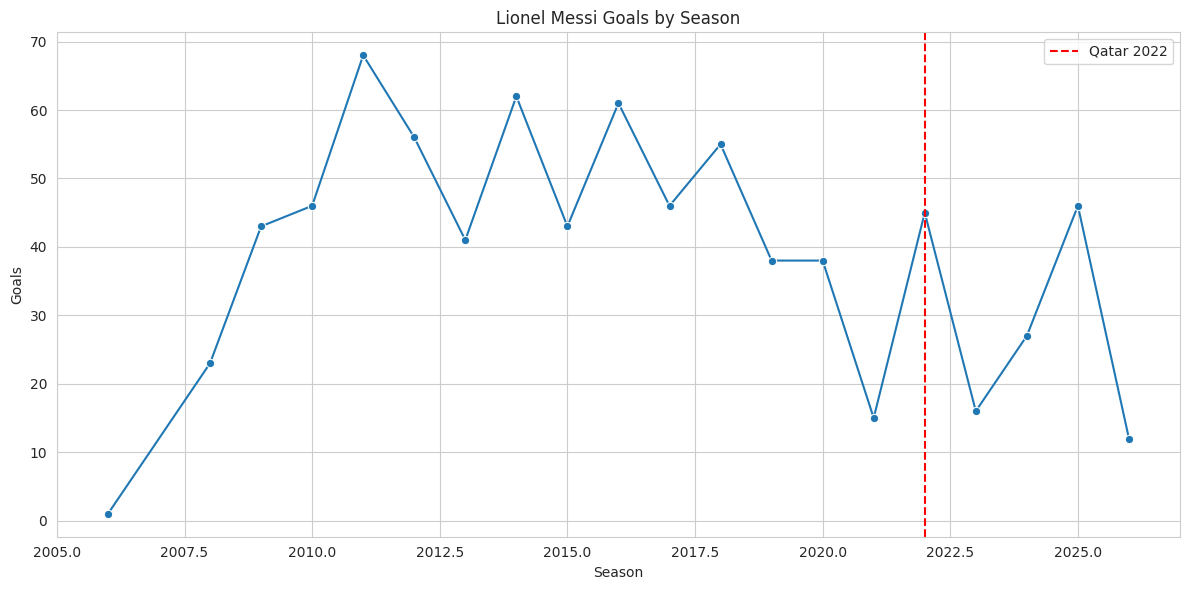

In [137]:
# plot Messi goals per season

sns.lineplot(data=messi_season, x="season_year", y="goals", marker="o")

# mark the 2022 World Cup with a red vertical line
plt.axvline(x=2022, color="red", linestyle="--", label="Qatar 2022")

# chart titles and labels
plt.title("Lionel Messi Goals by Season")
plt.xlabel("Season")
plt.ylabel("Goals")

plt.legend()

plt.tight_layout()

plt.show()

### Insight

Messi's goal scoring ability was already extremely high before the 2022 World Cup.
This shows that his scoring greatness existed long before Qatar.

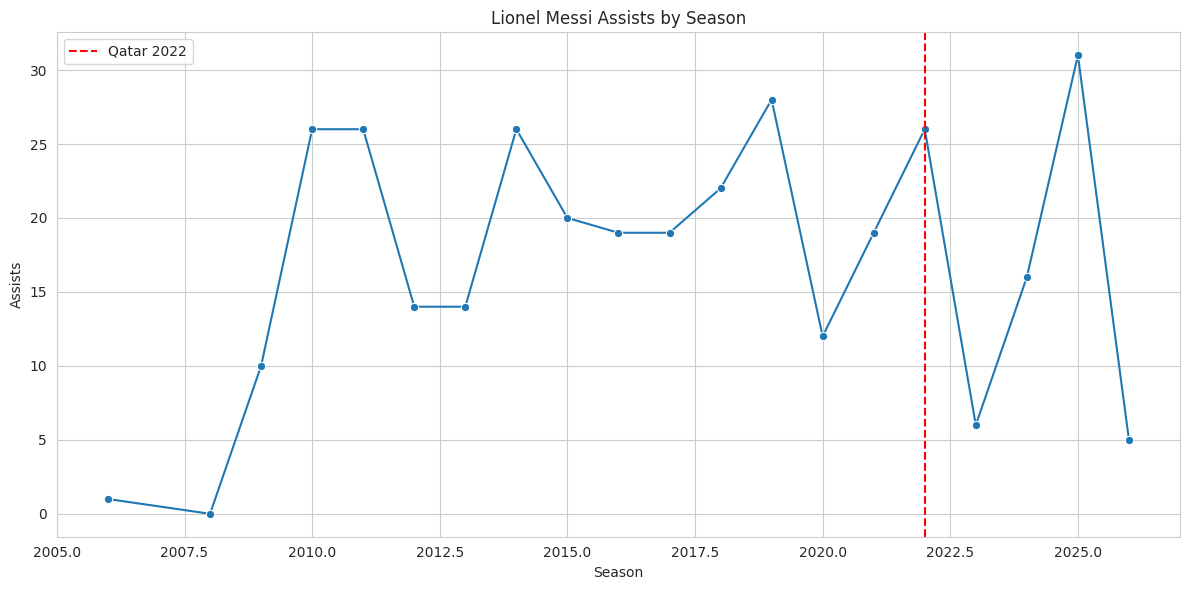

In [138]:
# plot Messi assists per season

sns.lineplot(data=messi_season, x="season_year", y="assists", marker="o")

# mark the 2022 World Cup
plt.axvline(x=2022, color="red", linestyle="--", label="Qatar 2022")

# titles and labels
plt.title("Lionel Messi Assists by Season")
plt.xlabel("Season")
plt.ylabel("Assists")

plt.legend()

plt.tight_layout()

plt.show()

### Insight

Messi consistently contributed as a playmaker.
Over time he evolved from a pure scorer into a more complete attacking player.

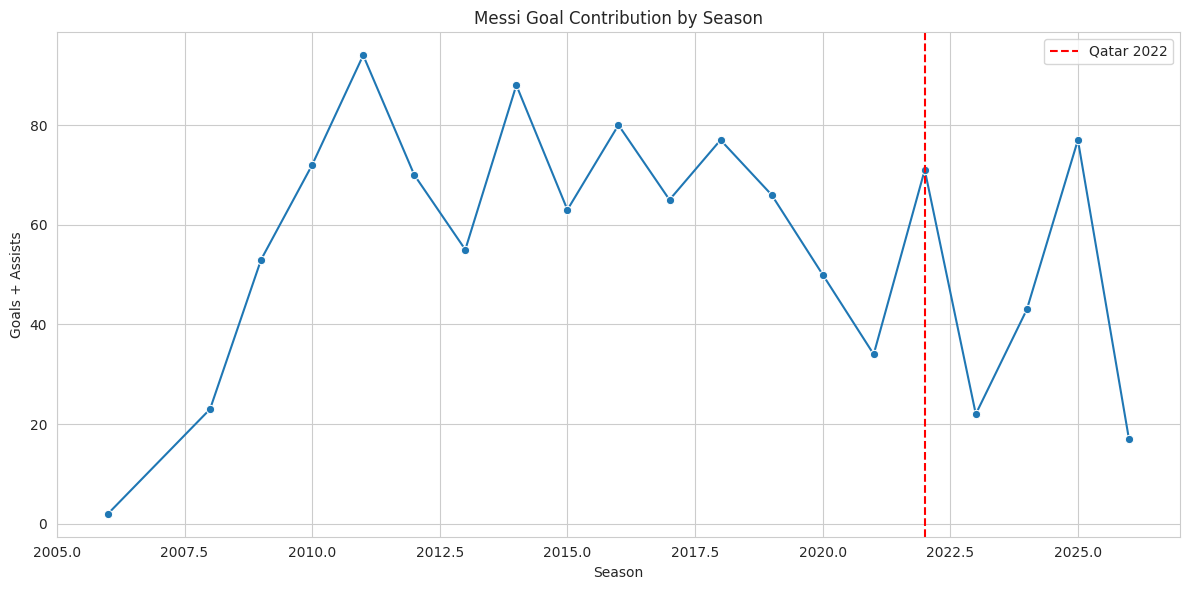

In [139]:
# plot Messi total attacking contribution (goals + assists)

sns.lineplot(data=messi_season, x="season_year", y="goal_contribution", marker="o")

# mark the World Cup year
plt.axvline(x=2022, color="red", linestyle="--", label="Qatar 2022")

# titles
plt.title("Messi Goal Contribution by Season")
plt.xlabel("Season")
plt.ylabel("Goals + Assists")

plt.legend()

plt.tight_layout()

plt.show()

### Insight

Goal contribution provides a more complete view of Messi's attacking impact.
Even when his role evolved, his total contribution remained very high.

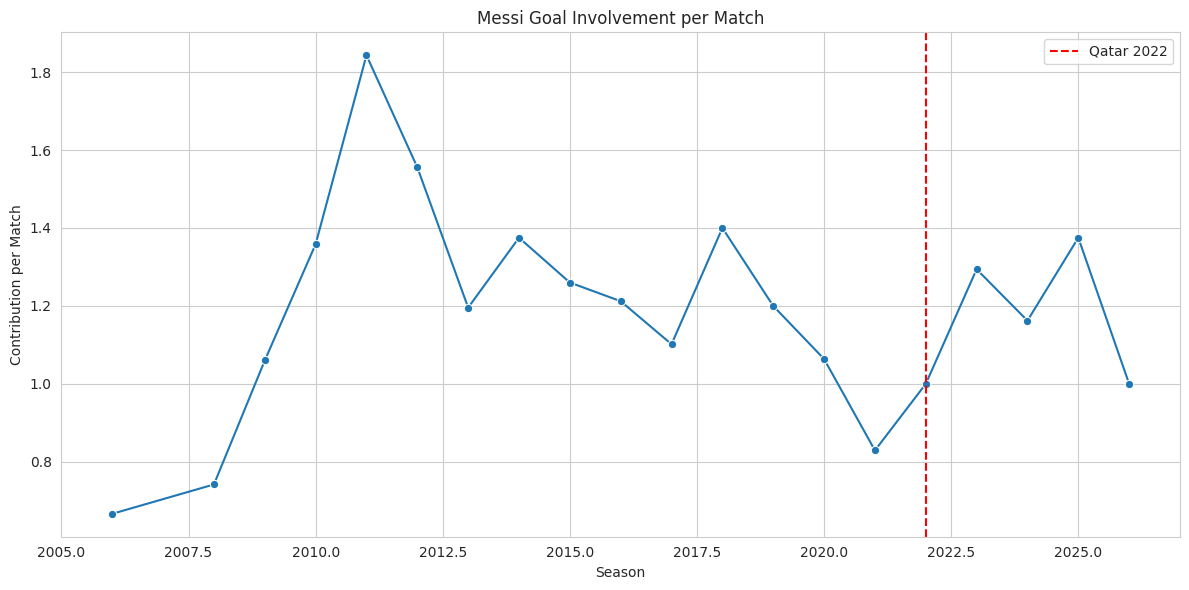

In [140]:
# plot Messi goal involvement per match (efficiency metric)

sns.lineplot(data=messi_season, x="season_year", y="involvement_per_match", marker="o")

# mark Qatar 2022
plt.axvline(x=2022, color="red", linestyle="--", label="Qatar 2022")

# titles
plt.title("Messi Goal Involvement per Match")
plt.xlabel("Season")
plt.ylabel("Contribution per Match")

plt.legend()

plt.tight_layout()

plt.show()

### Insight

This metric measures Messi's efficiency.
He remained highly involved in goals across most seasons of his career.

## Summary Metrics Before and After Qatar 2022

Now we compare Messi's average performance before and after the World Cup.

In [141]:
# calculate average performance before and after Qatar 2022

summary_metrics = messi_season.groupby("period")[[
    "goals_per_match",
    "assists_per_match",
    "involvement_per_match"
]].mean()

summary_metrics

,goals_per_match,assists_per_match,involvement_per_match
period,,,
Post-Qatar,0.766404,0.399852,1.166256
Pre-Qatar,0.844680,0.346210,1.190890


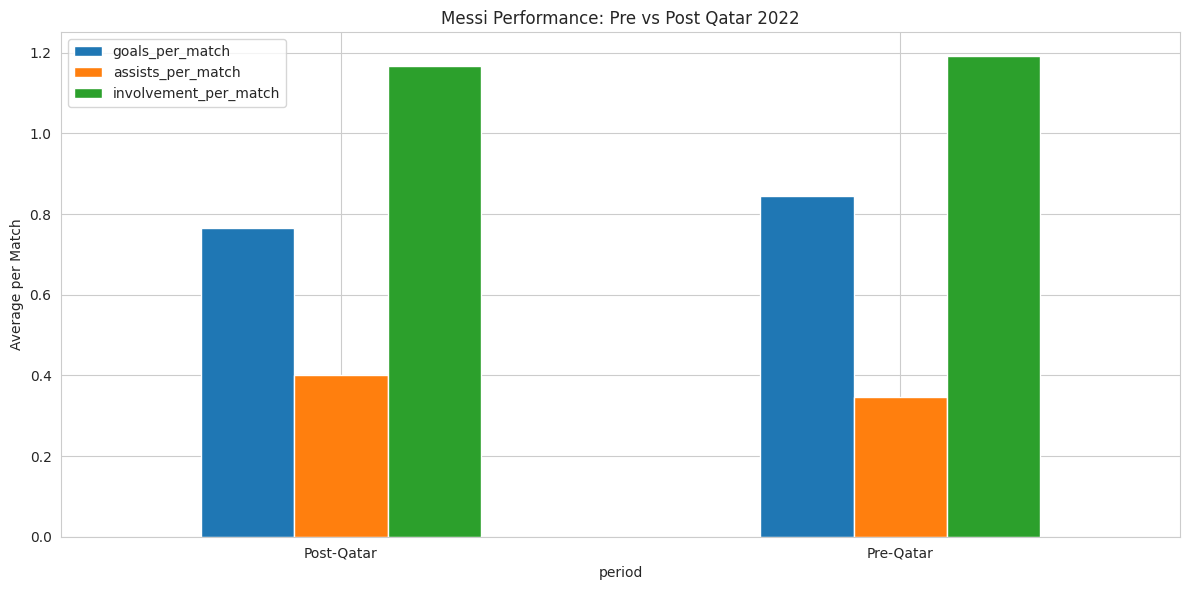

In [142]:
# create bar chart comparing the two periods

summary_metrics.plot(kind="bar")

plt.title("Messi Performance: Pre vs Post Qatar 2022")

plt.ylabel("Average per Match")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Insight

Messi's performance remained strong after the World Cup.

However, the biggest change after Qatar appears in public perception rather
than in raw performance numbers.

## Distribution of Goal Involvement

This boxplot shows the distribution of Messi's goal involvement per match
before and after the 2022 World Cup.

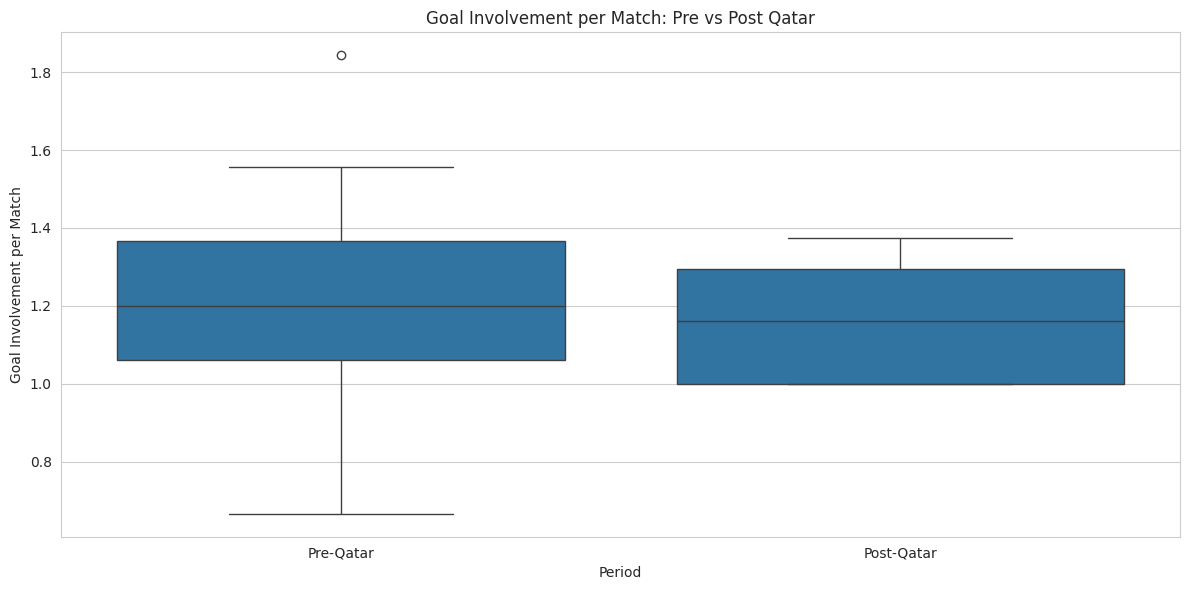

In [146]:
# visualize distribution of goal involvement before and after Qatar

sns.boxplot(data=messi_season, x="period", y="involvement_per_match")

plt.title("Goal Involvement per Match: Pre vs Post Qatar")

plt.xlabel("Period")
plt.ylabel("Goal Involvement per Match")

plt.tight_layout()

plt.show()

### Insight

This chart helps us see not only the average level, but also the consistency of Messi's involvement in goals before and after Qatar.

## Media Narrative Analysis

In this section we analyze how media headlines changed before and after the 2022 World Cup.

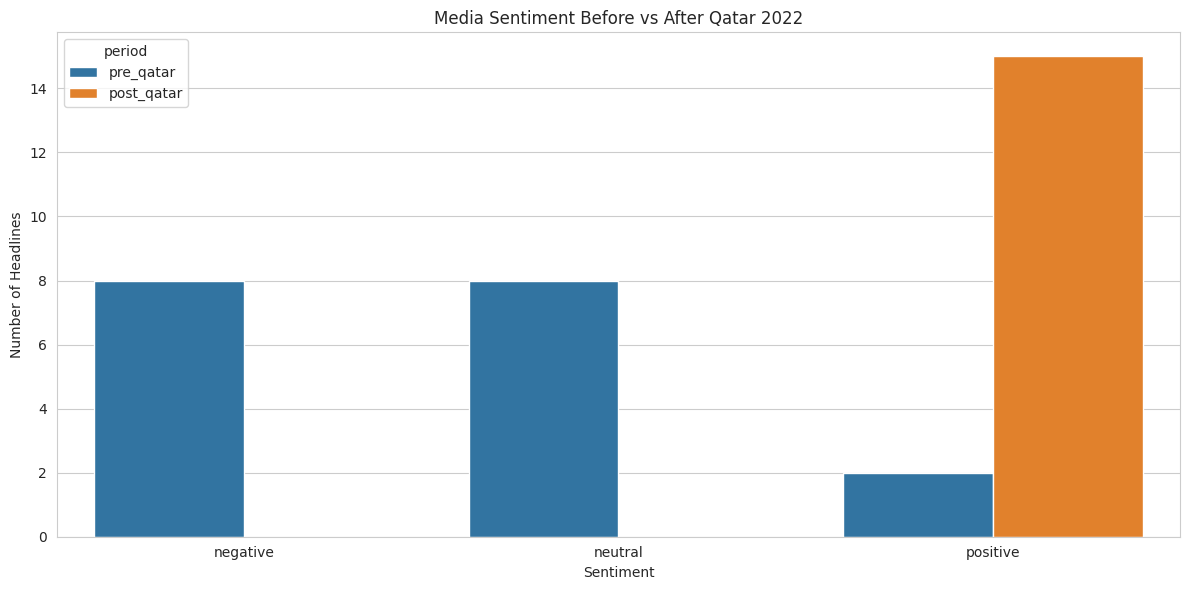

In [145]:
# plot sentiment of headlines

sns.countplot(data=headlines, x="sentiment", hue="period")

plt.title("Media Sentiment Before vs After Qatar 2022")
plt.xlabel("Sentiment")
plt.ylabel("Number of Headlines")

plt.tight_layout()

plt.show()

### Insight

Before the World Cup, headlines were more mixed and sometimes critical.

After Argentina won the tournament, the media narrative became much more positive.

## Conclusion

This project analyzed Lionel Messi's performance across his career
and compared it with media narratives before and after the 2022 World Cup.

The statistical data shows that Messi's performance was already elite long before Qatar.

However, the biggest shift after the World Cup appears in media perception and public narrative.

### Final Insight

The World Cup did not create Messi's greatness.

It confirmed it in the eyes of the world.